In [5]:
import pandas as pd
from pathlib import Path
import numpy as np
from common.consts import proteins, thresholds, res_colors

%load_ext autoreload
%autoreload 2

In [4]:
# import numpy as np
# import pandas as pd
# from pathlib import Path

# thresholds = np.arange(0.1, 0.50 + 1e-9, 0.04)
# all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}

# def read_colvar_with_fields(path):
#     with open(path, "r") as f:
#         header = f.readline().strip()
#     parts = header.split()
#     if len(parts) < 3 or parts[0] != "#!" or parts[1] != "FIELDS":
#         raise ValueError(f"Unexpected FIELDS header in {path}: {header}")
#     names = parts[2:]
#     return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

# for protein in proteins:
#     base_path = Path(f"../data/{protein}/output")
#     for i in range(4000, 4201):
#         index_str = f"{i:03}"
#         candidates = [
#             base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}",
#             base_path / f"run_{index_str}" / f"COLVAR_{index_str}",
#         ]
#         run_path = next((p for p in candidates if p.exists()), None)
#         if run_path is None:
#             print(f"Missing: {candidates[0]} and {candidates[1]}")
#             continue

#         try:
#             df = read_colvar_with_fields(run_path)
#         except FileNotFoundError:
#             print(f"Missing: {run_path}")
#             continue

#         if not {"time", "metad.acc", "rmsd"}.issubset(df.columns):
#             print(f"Missing required columns in {run_path}")
#             continue

#         passed = set()
#         for _, row in df.iterrows():
#             time = row["time"]
#             acc = row["metad.acc"]
#             rmsd = row["rmsd"]
#             predicted = time * acc
#             for th in thresholds:
#                 if th not in passed and rmsd > th:
#                     all_mfpt[protein][th].append(predicted)
#                     passed.add(th)
#             if len(passed) == len(thresholds):
#                 break


In [5]:
# import pickle

# with open("../data/mfpt-pace=25000.pkl", "wb") as f:
#     pickle.dump(all_mfpt, f)
# print(all_mfpt['chignolin'].keys())

p: 0.004009395535122084


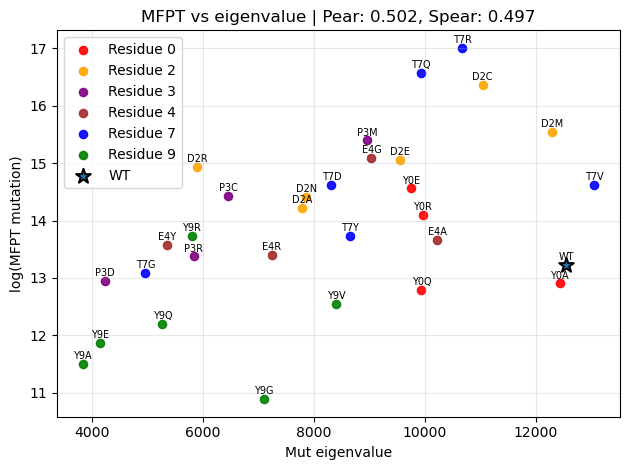

(np.float64(0.5019891082915582), np.float64(0.49677419354838714))

In [6]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from common.utils import collect_df  # only for isna in xlabel

def plot_mfpt_corr(df, prop_col, wt_label='WT', group_col='residue_idx',
                   annotate=False, th=None, log_prop=True):
    x_series = pd.to_numeric(df[prop_col], errors='coerce')
    y_series = pd.to_numeric(df['mfpt'], errors='coerce')

    y_log = np.log(y_series)
    valid_mask = x_series.notna() & y_log.replace([np.inf, -np.inf], np.nan).notna()

    x_all = x_series[valid_mask].to_numpy()
    y_all = y_log[valid_mask].to_numpy()
    names = df.index[valid_mask].to_numpy()

    x_map = x_series
    y_map = y_log

    if len(x_all) >= 2 and np.nanstd(x_all) > 0 and np.nanstd(y_all) > 0:
        pearson, p = stats.pearsonr(x_all, y_all)
    else:
        pearson, p = np.nan, np.nan

    if len(x_all) >= 2 and np.nanstd(y_all) > 0:
        spearman, _ = stats.spearmanr(x_all, y_all)
    else:
        spearman = np.nan

    print(f"p: {p}")

    for k in sorted(int(k) for k in df[group_col].dropna().unique()):
        sub_idx = df.index[df[group_col] == k]
        sub_mask = sub_idx.intersection(df.index[valid_mask])
        if len(sub_mask) == 0:
            continue
        plt.scatter(
            x_map.loc[sub_mask].to_numpy(),
            y_map.loc[sub_mask].to_numpy(),
            label=f"Residue {k}", s=35, alpha=0.9, c=res_colors.get(k)
        )

    wt_prop = x_map.get(wt_label, np.nan)
    wt_y = y_map.get(wt_label, np.nan)
    if np.isfinite(wt_prop) and np.isfinite(wt_y):
        plt.scatter(wt_prop, wt_y, s=120, marker='*', edgecolors='k', linewidths=1.5, label=wt_label)

    if annotate:
        for xv, yv, name in zip(x_all, y_all, names):
            if np.isfinite(xv) and np.isfinite(yv):
                plt.text(xv, yv + 0.05, name, fontsize=7, ha='center', va='bottom')

    xlabel = (f"Mut {prop_col}" if log_prop and not pd.isna(wt_prop) else prop_col)
    plt.xlabel(xlabel)
    plt.ylabel('log(MFPT mutation)')
    t = f" | Th={th:.3g}" if th is not None else ""
    pear_txt = "nan" if np.isnan(pearson) else f"{pearson:.3g}"
    spear_txt = "nan" if np.isnan(spearman) else f"{spearman:.3g}"
    plt.title(f"MFPT vs {prop_col}{t} | Pear: {pear_txt}, Spear: {spear_txt}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pearson, spearman


with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(False, all_mfpt, thresholds[3])

plot_mfpt_corr(df, 'eigenvalue', annotate=True)
# for short, v in (df['mfpt'] / 1e6).items():
#     print(f"{short}, {v:.3g}")
# # plot_mfpt_corr(df, 'enthalpy', annotate=True)
# # plot_mfpt_corr(df, 'Tm', annotate=True)
# # plot_mfpt_corr(df, 'abs_dvar_F', annotate=True)


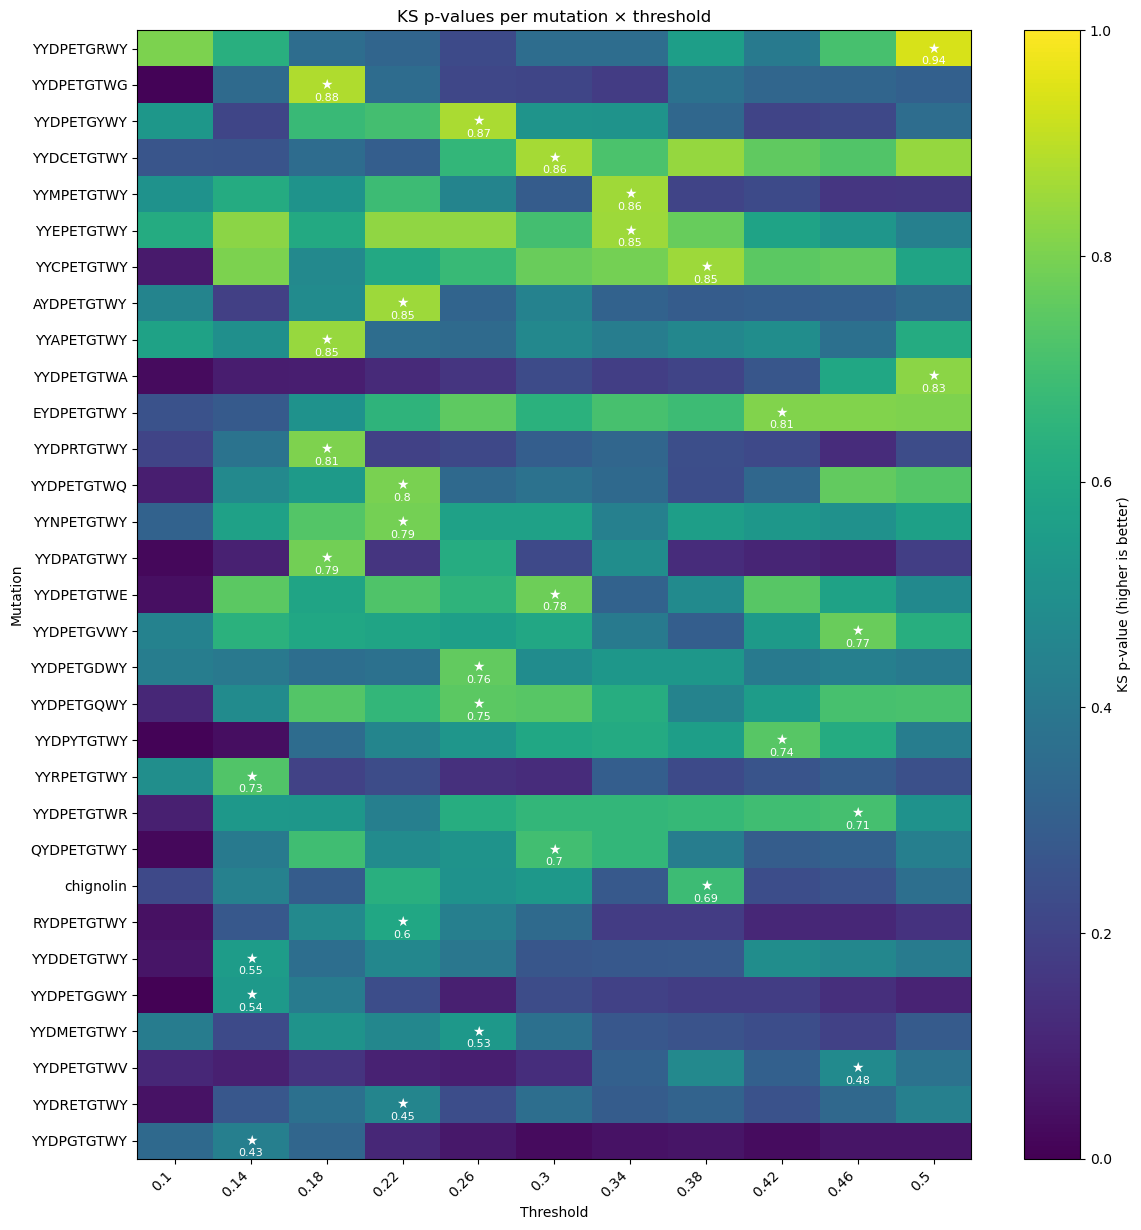

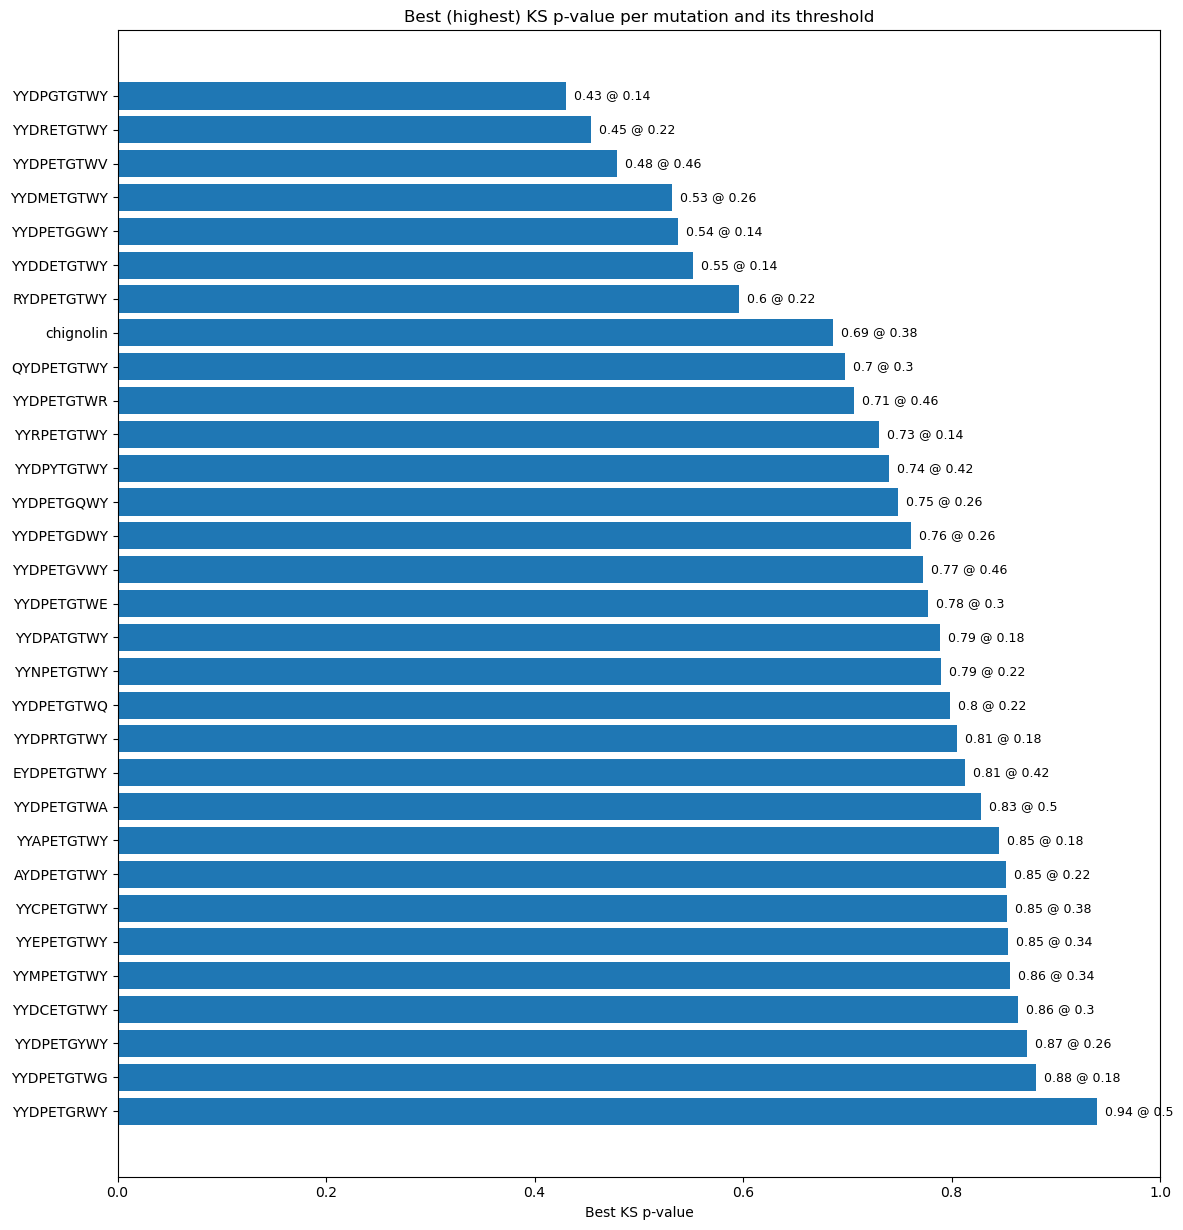

            best_pvalue  best_threshold
YYDPETGRWY        0.939             0.5
YYDPETGTWG       0.8813            0.18
YYDPETGYWY        0.872            0.26
YYDCETGTWY        0.864             0.3
YYMPETGTWY       0.8555            0.34
YYEPETGTWY       0.8537            0.34
YYCPETGTWY       0.8526            0.38
AYDPETGTWY       0.8517            0.22
YYAPETGTWY       0.8455            0.18
YYDPETGTWA       0.8279             0.5
EYDPETGTWY       0.8125            0.42
YYDPRTGTWY       0.8054            0.18
YYDPETGTWQ        0.798            0.22
YYNPETGTWY       0.7901            0.22
YYDPATGTWY       0.7885            0.18
YYDPETGTWE       0.7776             0.3
YYDPETGVWY       0.7729            0.46
YYDPETGDWY       0.7613            0.26
YYDPETGQWY       0.7485            0.26
YYDPYTGTWY       0.7402            0.42
YYRPETGTWY       0.7299            0.14
YYDPETGTWR       0.7061            0.46
QYDPETGTWY        0.698             0.3
chignolin        0.6858            0.38


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import stats, optimize
import pickle

from common.utils import estimateMFPT
from common.consts import proteins  # your list of mutation names

def fit_exp_ks(samples):
    x = np.array(samples, float)
    x.sort()
    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau): return 1 - np.exp(-t / tau)
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf,
                             p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, p, D

def collect_pvalues(all_mfpt, proteins, thresholds, min_samples=10):
    pvals = pd.DataFrame(index=proteins, columns=thresholds, dtype=float)
    lims  = pd.DataFrame(index=proteins, columns=thresholds, dtype=float)

    for p in proteins:
        for th in thresholds:
            s = np.sort(np.array(all_mfpt[p][th], float))
            if s.size < min_samples:
                pvals.loc[p, th] = np.nan
                lims.loc[p, th]  = np.nan
                continue
            _, lim = estimateMFPT(s, min_samples)
            lim = int(max(min_samples, min(lim, s.size)))
            _, pval, _ = fit_exp_ks(s[:lim])
            pvals.loc[p, th] = pval
            lims.loc[p, th]  = lim

    return pvals, lims

def summarize_best(pvals):
    best_th_idx = pvals.values.argmax(axis=1)
    best_th = pd.Series([pvals.columns[i] if not np.isnan(i) else np.nan
                         for i in best_th_idx], index=pvals.index, name="best_threshold")
    best_p  = pvals.max(axis=1).rename("best_pvalue")
    summary = pd.concat([best_p, best_th], axis=1)
    summary = summary.sort_values("best_pvalue", ascending=False)
    return summary

def plot_heatmap_with_marks(pvals, summary, title="KS p-values per mutation × threshold"):
    p_sorted = pvals.loc[summary.index]
    data = p_sorted.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(12, max(5, 0.4*len(p_sorted))))
    # Use a tiny epsilon to avoid log(0); show higher=brighter with a linear norm
    im = ax.imshow(np.clip(data, 1e-16, 1.0), aspect="auto", cmap="viridis",
                   vmin=0.0, vmax=1.0)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label("KS p-value (higher is better)")

    ax.set_xticks(range(p_sorted.shape[1]))
    ax.set_xticklabels([f"{th:.3g}" for th in p_sorted.columns], rotation=45, ha="right")
    ax.set_yticks(range(p_sorted.shape[0]))
    ax.set_yticklabels(p_sorted.index)

    # Mark the best cell per row with a star and annotate the p-value
    for i in range(p_sorted.shape[0]):
        row = data[i, :]
        j = np.nanargmax(row)
        ax.text(j, i, "★", ha="center", va="center", fontsize=10, color="white", weight="bold")
        ax.text(j, i+0.35, f"{row[j]:.2g}", ha="center", va="center", fontsize=8, color="white")

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Mutation")
    ax.set_title(title)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

def plot_best_bar(summary):
    fig, ax = plt.subplots(figsize=(12, max(4, 0.4*len(summary))))
    ax.barh(summary.index, summary["best_pvalue"])
    for i, (pval, th) in enumerate(zip(summary["best_pvalue"], summary["best_threshold"])):
        ax.text(pval, i, f"  {pval:.2g} @ {th:.3g}", va="center", fontsize=9)
    ax.set_xlabel("Best KS p-value")
    ax.set_title("Best (highest) KS p-value per mutation and its threshold")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

# --- run ---
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt["chignolin"].keys()), float)

pvals, lims = collect_pvalues(all_mfpt, proteins, thresholds, min_samples=10)
summary = summarize_best(pvals)

# 1) Heatmap with stars on the best threshold per mutation
plot_heatmap_with_marks(pvals, summary)

# 2) Optional compact bar chart of best p-values with the winning threshold
plot_best_bar(summary)

# 3) If you want a tidy table to print/save:
print(summary.to_string(float_format=lambda x: f"{x:.4g}"))


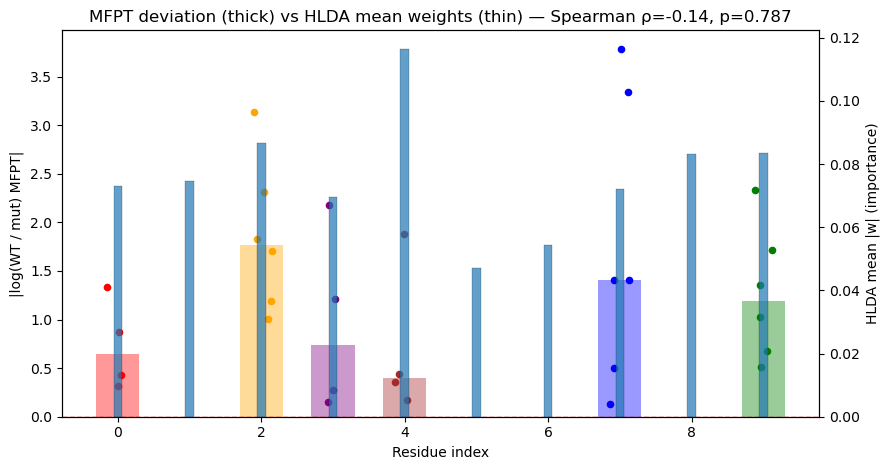

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

importance = {4:0.1165, 2:0.0868, 9:0.0834, 8:0.0833, 1:0.0747, 0:0.0730, 7:0.0720, 3:0.0697, 6:0.0544, 5:0.0471}

wt = float(df.loc['WT', 'mfpt'])

med_abs = {}
dist_by_res = {}
for i, g in df.groupby("residue_idx"):
    i = int(i)
    r = np.log(wt / g['mfpt'].to_numpy())
    d = np.abs(r)
    med_abs[i] = np.median(d)
    dist_by_res[i] = d

residues = sorted(set(range(10)) | set(importance.keys()) | set(med_abs.keys()))

fig, ax = plt.subplots(figsize=(9,4.8))
for i in residues:
    if i in med_abs:
        ax.bar(i, med_abs[i], color=res_colors[i], alpha=0.4, width=0.6)
        d = dist_by_res[i]
        x_jitter = np.random.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(np.full(len(d), i) + x_jitter, d, color=res_colors[i], s=20, zorder=3)

ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel("Residue index")
ax.set_ylabel("|log(WT / mut) MFPT|")

ax2 = ax.twinx()
imp_vals = [importance.get(i, np.nan) for i in residues]
ax2.bar(residues, imp_vals, width=0.12, alpha=0.7, edgecolor='k', linewidth=0.2)
ax2.set_ylabel("HLDA mean |w| (importance)")

x = np.array([med_abs.get(i, np.nan) for i in residues], float)
y = np.array([importance.get(i, np.nan) for i in residues], float)
mask = ~np.isnan(x) & ~np.isnan(y)
rho, p = spearmanr(x[mask], y[mask]) if mask.any() and mask.sum()>1 else (np.nan, np.nan)
ax.set_title(f"MFPT deviation (thick) vs HLDA mean weights (thin) — Spearman ρ={rho:.2f}, p={p:.3g}")

fig.tight_layout()
plt.show()


0.18000000000000002
1088755.6167755118 14


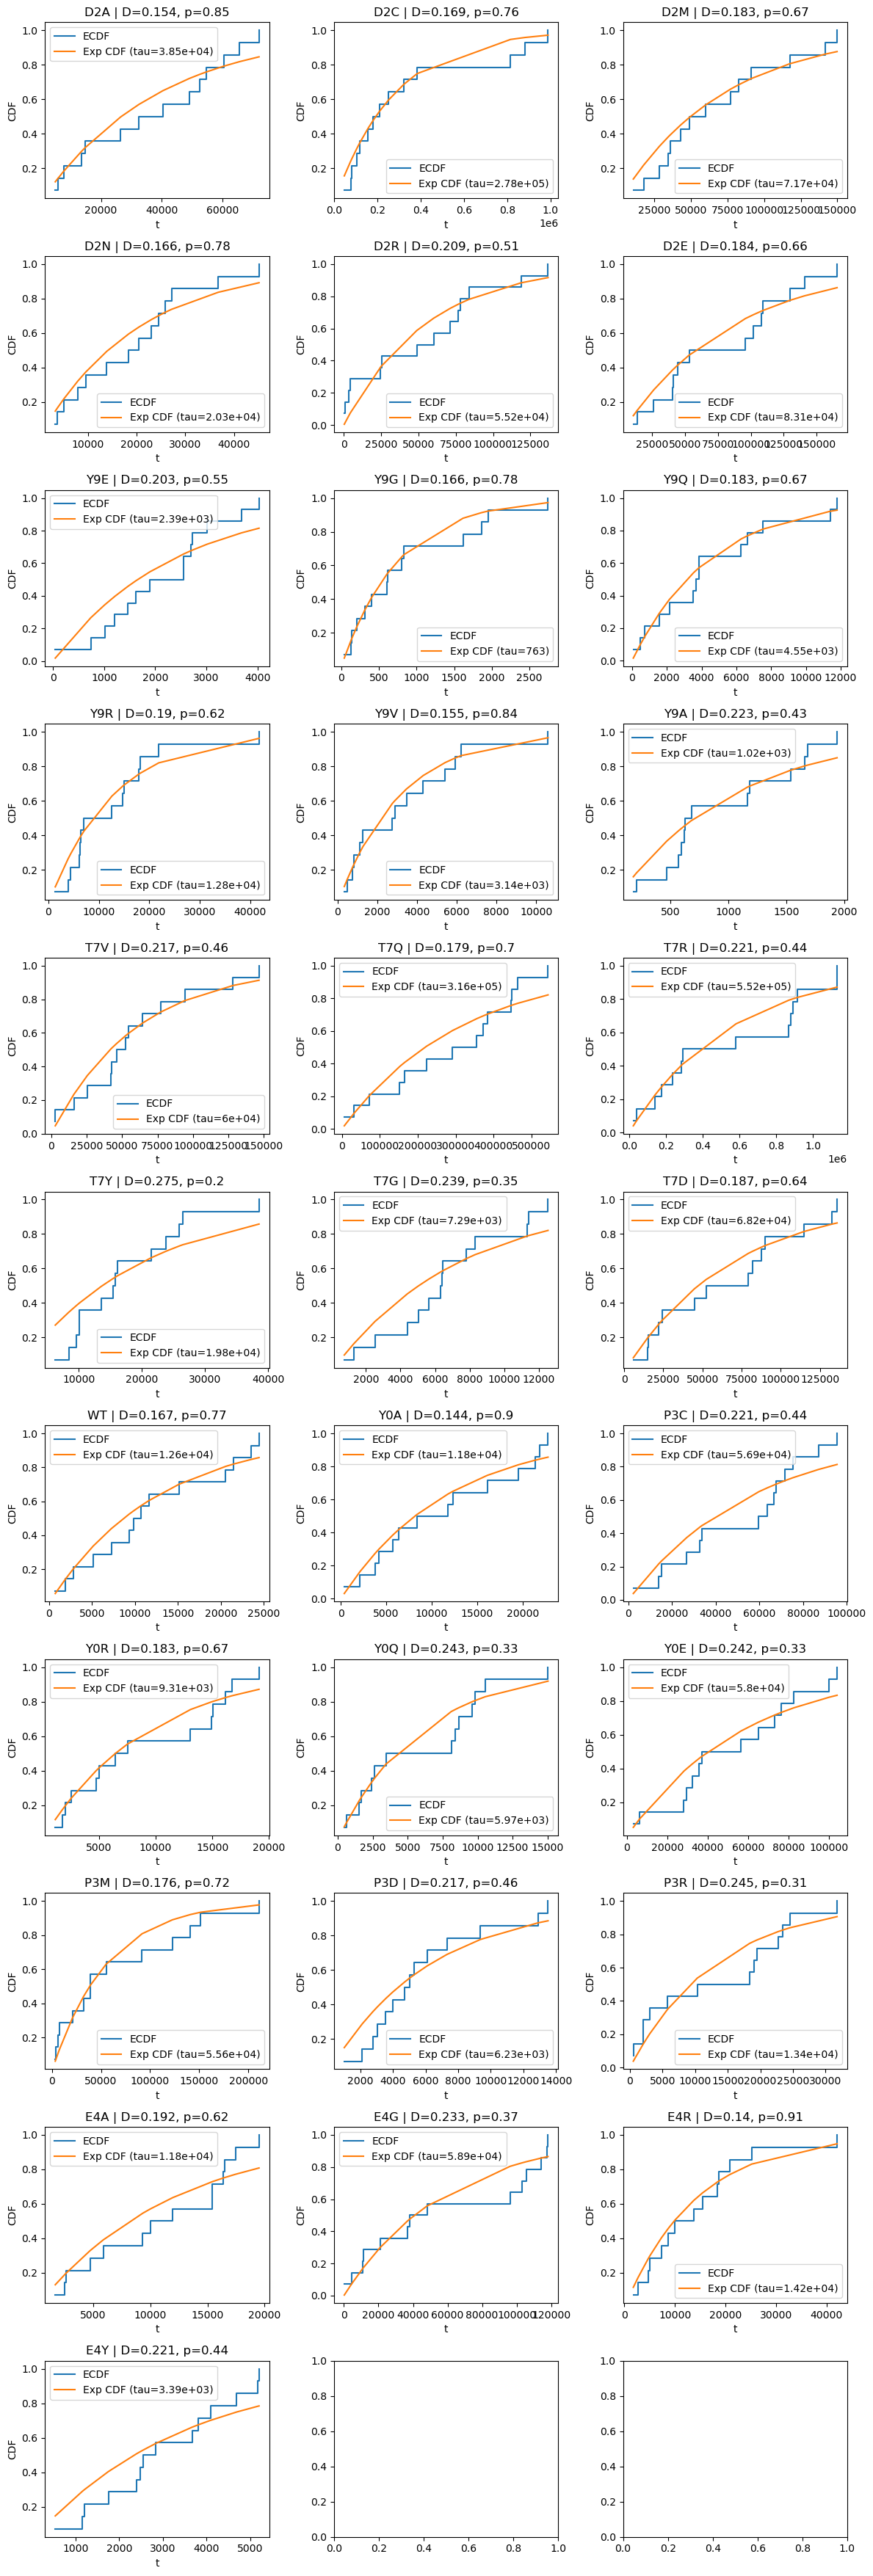

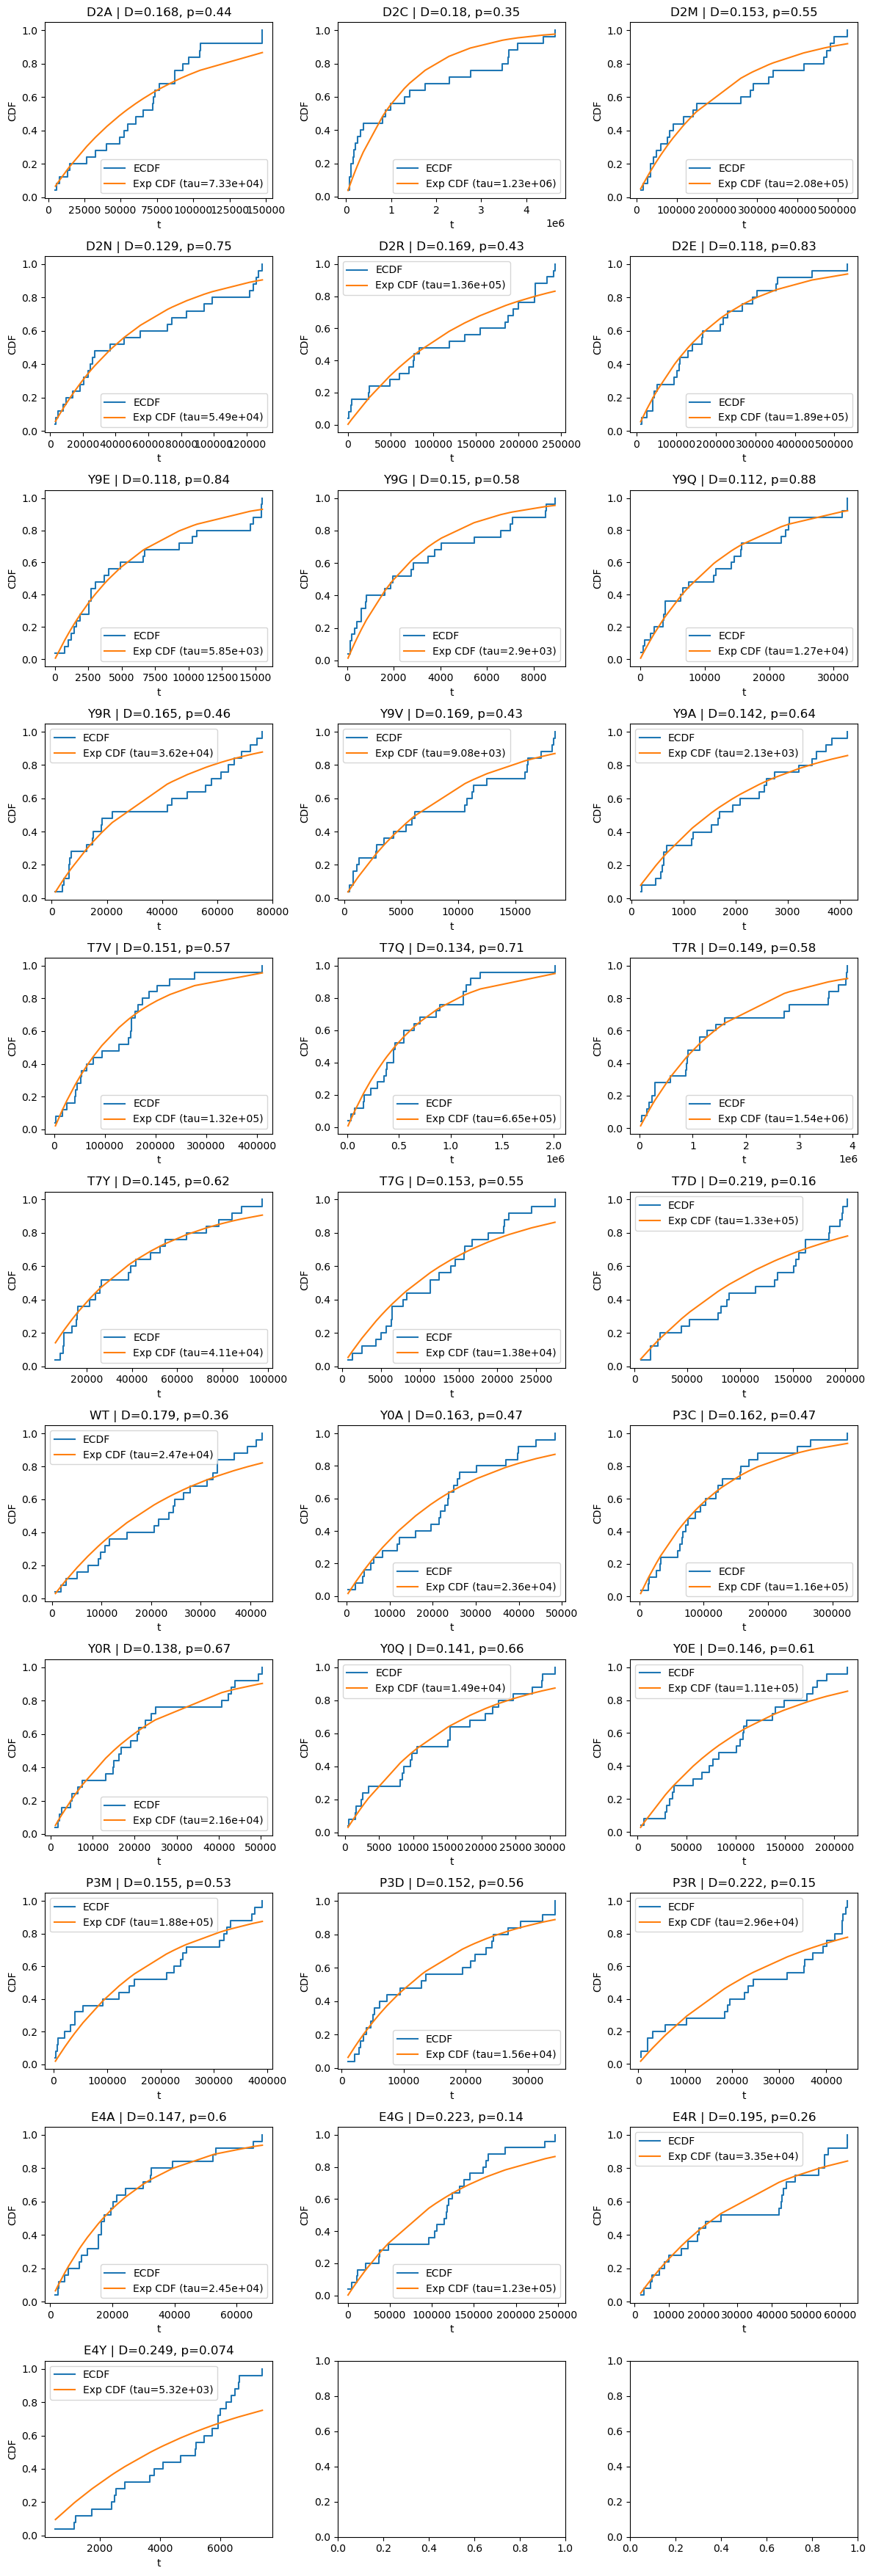

In [12]:
import math 
from common.consts import long_to_short

def fit_exp_ecdf(samples, ax):
    x = np.array(samples)

    n = x.size
    def F(t, tau): return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)

    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    D, p = stats.kstest(x, "expon", args=(0, tau))
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.legend(); ax.set_title(f"D={D:.3g}, p={p:.2g}")
    return tau, D, p, ax

def ks_table_fastest_k(all_mfpt, names, th, k):
    rows = []
    for name in names:
        s = np.array(all_mfpt[name][th])
        s.sort()
        
        s = s[:k]
        tau, p, D = fit_exp_ks(s)
        rows.append({"name": name, "n": s.size, "tau": tau, "ks_p": p, "ks_D": D})
    return pd.DataFrame(rows).sort_values("ks_p", ascending=False)

def plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = None ):
    ncols=3
    m = len(names)
    nrows = math.ceil(m / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        if k == None:
            mfpt_base, k = estimateMFPT(np.array(all_mfpt[name][th]), 10)
            print(mfpt_base, k)

        s = np.sort(np.array(all_mfpt[name][th]))[:k]
        fit_exp_ecdf(s, ax=axes[r, c])
        axes[r, c].set_title(f"{long_to_short[name]} | " + axes[r, c].get_title())
        
    fig.tight_layout()
    return fig

th = np.array(list(all_mfpt['chignolin'].keys()))[2]
print(th)
names = list(proteins)
k = 25
res = ks_table_fastest_k(all_mfpt, names, th, k = k)

plot_ecdfs_grid_fastest_k(all_mfpt, names, th)
plt.show()

plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = k)
plt.show()

def compare_k_vs_dynamic(all_mfpt, names, th, k = k):
    rows = []
    for name in names:
        s_all = np.sort(np.array(all_mfpt[name][th]))

        s_fixed = s_all[:k]
        fig, ax = plt.subplots()
        tau_f, D_f, p_f, _ = fit_exp_ecdf(s_fixed, ax=ax)
        plt.close(fig)

        # Dynamic k from estimateMFPT
        _, k_dyn = estimateMFPT(s_all, 10)
        s_dyn = s_all[:k_dyn]
        fig, ax = plt.subplots()
        tau_d, D_d, p_d, _ = fit_exp_ecdf(s_dyn, ax=ax)
        plt.close(fig)

        rows.append({
            "name": name,
            "k_fixed": k, "tau_fixed": tau_f, "D_fixed": D_f, "p_fixed": p_f,
            "k_dyn": k_dyn, "tau_dyn": tau_d, "D_dyn": D_d, "p_dyn": p_d
        })

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(df["D_fixed"], df["D_dyn"])
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel(f"D (k={k})")
    axes[0].set_ylabel("D (dynamic k)")
    axes[0].set_title("KS D comparison")

    axes[1].scatter(df["p_fixed"], df["p_dyn"])
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel(f"p-value (k={k})")
    axes[1].set_ylabel("p-value (dynamic k)")
    axes[1].set_title("KS p-value comparison")

    fig.tight_layout()
    return df, fig

# df_comparison, fig_cmp = compare_k_vs_dynamic(all_mfpt, names, th)
# plt.show()


In [ ]:
# %load_ext autoreload
# %autoreload 2

# from pathlib import Path
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import optimize, stats
# from common.utils import estimateMFPT
# import warnings

# warnings.filterwarnings("ignore", category=FutureWarning)

# PROTEINS = ['YYAPETGTWY','YYCPETGTWY','YYDPETGQWY', 'YYDPETGRWY']
# RANGES = [(4000, 4200), (3000, 3200), (3201, 3400)]
# THRESHOLDS = np.round(np.arange(0.1, 0.5 + 1e-9, 0.05), 2)

# def read_colvar(path: Path) -> pd.DataFrame:
#     with path.open() as f:
#         for line in f:
#             if line.startswith("#! FIELDS"):
#                 names = line.replace("#! FIELDS", "").strip().split()
#                 break
#         else:
#             raise ValueError(f"No FIELDS header in {path}")
#     return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

# def first_cross_times(df: pd.DataFrame, thresholds):
#     rmsd = df['rmsd'].to_numpy()
#     t = df['time'].to_numpy()
#     acc = df['metad.acc'].to_numpy()
#     out = {}
#     for th in thresholds:
#         idx = np.flatnonzero(rmsd > th)
#         out[float(th)] = None if idx.size == 0 else float(t[idx[0]] * acc[idx[0]])
#     return out

# def fit_tau_and_pvalue(samples):
#     x = np.array(sorted(samples, key=float))
#     n = len(x)
#     ecdf = np.arange(1, n + 1) / n
#     tau = optimize.curve_fit(lambda tt, tau: 1 - np.exp(-tt / tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
#     f = np.random.exponential(tau, size=max(10000, 10*n))
#     p = stats.ks_2samp(x, f, alternative="two-sided", method="asymp")[1]
#     return tau, p

# def gather_samples_multi(protein: str, start: int, stop: int, thresholds):
#     base = Path(f"../data/{protein}/output")
#     buckets = {float(th): [] for th in thresholds}
#     for i in range(start, stop):
#         p = base / f"run_{i}" / f"HLDA_COLVAR_{i}"
#         if not p.exists():
#             print(f"Missing file: {p}")
#             continue
#         df = read_colvar(p)
#         crosses = first_cross_times(df, thresholds)
#         for th, val in crosses.items():
#             if val is not None:
#                 buckets[th].append(val)
#     rows = []
#     for th, arr in buckets.items():
#         if not arr:
#             rows.append(dict(thresh=th, mfpt=None, k=None, pvalue=None, n=0))
#             continue
#         arr = np.array(arr, float)
#         mfpt, k = estimateMFPT(arr, 15)
#         tau, pval = fit_tau_and_pvalue(arr)
#         rows.append(dict(thresh=th, mfpt=mfpt, k=k, pvalue=pval, n=len(arr)))
#     return pd.DataFrame(rows)

# all_rows = []
# for protein in PROTEINS:
#     for (a, b) in RANGES:
#         res = gather_samples_multi(protein, a, b, THRESHOLDS)
#         res['protein'] = protein
#         res['start'] = a
#         res['stop'] = b
#         all_rows.append(res)

# res = pd.concat(all_rows, ignore_index=True)
# print(res)

# fig1, axes1 = plt.subplots(len(PROTEINS), 1, figsize=(6, 4*len(PROTEINS)), squeeze=False)
# for ax, protein in zip(axes1.ravel(), PROTEINS):
#     sub = res[(res.protein==protein) & res.mfpt.notna()]
#     for (a,b), g in sub.groupby(["start","stop"]):
#         g = g.sort_values("thresh")
#         ax.plot(g.thresh, g.mfpt*1e-6, marker="o", label=f"{a}-{b-1}")
#     ax.set_title(f"{protein} — MFPT vs threshold")
#     ax.set_xlabel("threshold")
#     ax.set_ylabel("MFPT (µs)")
#     ax.legend()
# plt.tight_layout()
# plt.show()

# fig2, axes2 = plt.subplots(len(PROTEINS), 1, figsize=(6, 4*len(PROTEINS)), squeeze=False)
# for ax, protein in zip(axes2.ravel(), PROTEINS):
#     sub = res[(res.protein==protein) & res.pvalue.notna()]
#     for (a,b), g in sub.groupby(["start","stop"]):
#         g = g.sort_values("thresh")
#         ax.plot(g.thresh, g.pvalue, marker="s", label=f"{a}-{b-1}")
#     ax.set_title(f"{protein} — KS p-value vs threshold")
#     ax.set_xlabel("threshold")
#     ax.set_ylabel("p-value")
#     ax.legend()
# plt.tight_layout()
# plt.show()


/rg/mendels_prj/alexander.z/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/rg/mendels_prj/alexander.z/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


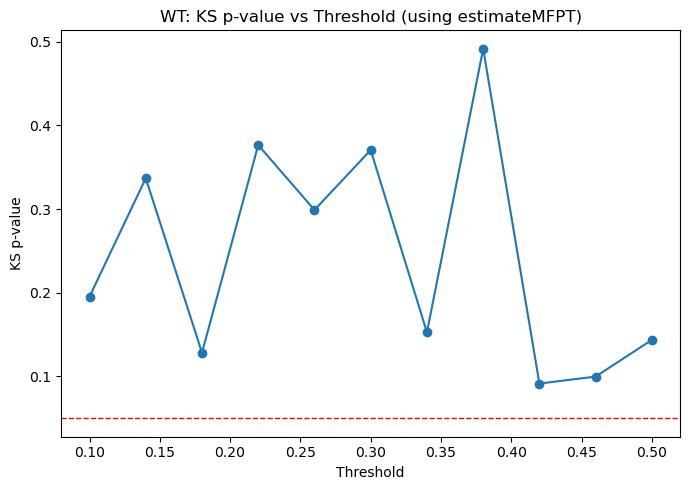